In [1]:
#Imports
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
%matplotlib inline
from matplotlib import pyplot as plt
import pandas as pd



In [2]:
# load the classic iris dataset
iris=load_iris()
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [3]:
# Turn the raw data into a readable table
df=pd.DataFrame(iris.data,columns=iris.feature_names)
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [4]:
#Using MinMaxScaler to scale all features
scaler= MinMaxScaler()
df[iris.feature_names]= scaler.fit_transform(df[iris.feature_names])


In [5]:
#Finding number of clusters(k) with elbow method
sse=[]
k_rng=range(1,10)
for k in k_rng:
    km=KMeans(n_clusters=k,n_init=10)
    km.fit(df)
    sse.append(km.inertia_)

    

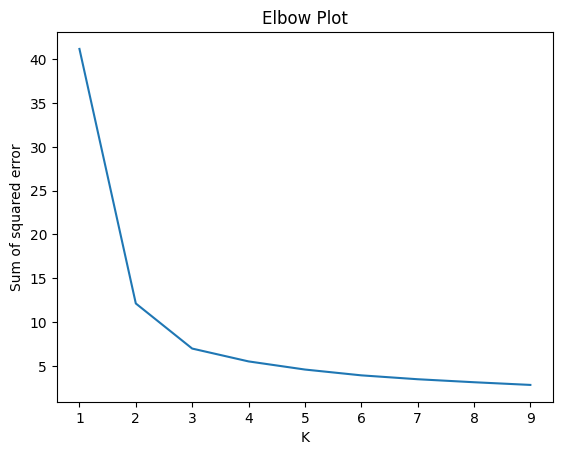

In [6]:
# Looking for the 'elbow'—where adding more clusters stops giving us a big change
plt.title('Elbow Plot')
plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(k_rng, sse)

In [7]:
# Based on the elbow plot,creating clusters
km=KMeans(n_clusters=3,n_init=10)
yp=km.fit_predict(df)
df['cluster']=yp
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),cluster
0,0.222222,0.625000,0.067797,0.041667,1
1,0.166667,0.416667,0.067797,0.041667,1
2,0.111111,0.500000,0.050847,0.041667,1
3,0.083333,0.458333,0.084746,0.041667,1
4,0.194444,0.666667,0.067797,0.041667,1
...,...,...,...,...,...
145,0.666667,0.416667,0.711864,0.916667,0
146,0.555556,0.208333,0.677966,0.750000,2
147,0.611111,0.416667,0.711864,0.791667,0
148,0.527778,0.583333,0.745763,0.916667,0


In [8]:
# Break the data into groups for plotting
df1=df[df.cluster==0]
df2=df[df.cluster==1]
df3=df[df.cluster==2]


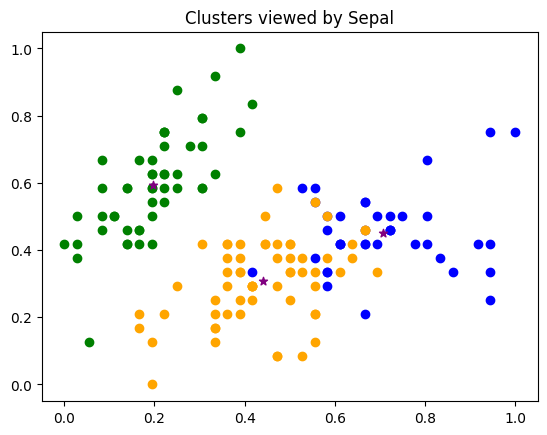

In [9]:
# Plot sepal length vs sepal width, each color represents one cluster
plt.title('Clusters viewed by Sepal')
plt.scatter(df1['sepal length (cm)'], df1['sepal width (cm)'], color='blue')
plt.scatter(df2['sepal length (cm)'], df2['sepal width (cm)'], color='green')
plt.scatter(df3['sepal length (cm)'], df3['sepal width (cm)'], color='orange')
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1], color='purple', marker='*' )
plt.show() 


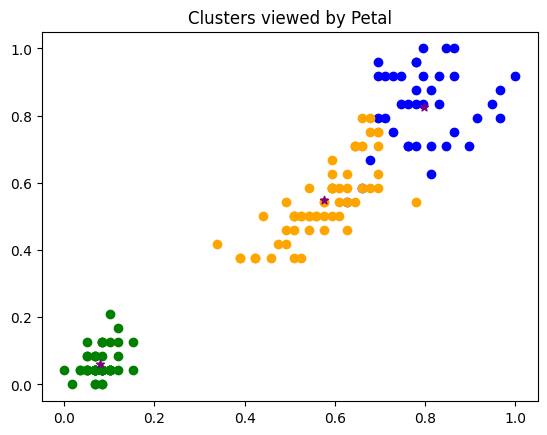

In [10]:
# Plot petal length vs petal width, each color represents one cluster
plt.title('Clusters viewed by Petal')
plt.scatter(df1['petal length (cm)'], df1['petal width (cm)'], color='blue')
plt.scatter(df2['petal length (cm)'], df2['petal width (cm)'], color='green')
plt.scatter(df3['petal length (cm)'], df3['petal width (cm)'], color='orange')
plt.scatter(km.cluster_centers_[:,2], km.cluster_centers_[:,3], color='purple', marker='*')
